# tblastn Truth Breakdown: Raw Real-World

Annotated records are kept as-is to show performance under real annotation noise.

Generated artifacts are written to `outputs/`.

## What To Look At

Use the summary first, then inspect failure modes and review cases. `coord_pct` is the main score: same canonical name and IoU >= 0.90 against the annotated truth feature.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from app.validation._shared.validation_utils import *

TIER = 'raw_realworld'
BASE_DIR = Path.cwd()
if not (BASE_DIR / 'inputs').exists() and (BASE_DIR / 'tiers' / TIER / 'inputs').exists():
    BASE_DIR = BASE_DIR / 'tiers' / TIER

INPUT_DIR = BASE_DIR / 'inputs'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

FAILURE_COLORS = {
    'Correct': '#2f7d4f',
    'Boundary offset': '#75b66b',
    'Wrong coords': '#d6a13d',
    'Alias/name gap': '#8f6bb1',
    'Possible overlap': '#e28e50',
    'Not lifted': '#c44e52',
    'Not in truth': '#7b8794',
}


## Tier Inputs

The manifest records which source records were kept or rejected for this tier. The GenBank files in `inputs/` are the actual records used below.

In [2]:
manifest = pd.read_csv(INPUT_DIR / 'manifest.tsv', sep='	')
tier_input_summary = pd.read_csv(INPUT_DIR / 'summary.tsv', sep='	')
tier_input_summary

,virus,reason,records,kept
0,FMD,kept_raw,98,98
1,FMD,no_truth_features,2,0
2,PRRS,kept_raw,100,100


## Run tblastn Against Tier Truth

This uses the same `run_tblastn_against_truth` helper as the original breakdown notebook, but swaps the query files for this tier's cleaned inputs.

In [3]:
DATASETS = [
    ('PRRS', DATA / 'PRRS_ref_test.gb', INPUT_DIR / 'PRRS_records.gb'),
    ('FMD', DATA / 'FMD_ref_test.gb', INPUT_DIR / 'FMD_records.gb'),
]

frames = []
summaries = []
for virus, ref_path, query_path in DATASETS:
    records = load_genbank_records(query_path)
    if not records:
        continue
    df, summary = run_tblastn_against_truth(virus, ref_path, query_path, OUTPUT_DIR / virus.lower())
    if not df.empty:
        frames.append(df)
    if not summary.empty:
        summaries.append(summary)

tblastn_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
tblastn_summary = pd.concat(summaries, ignore_index=True) if summaries else pd.DataFrame()

tblastn_df.to_csv(OUTPUT_DIR / 'tblastn_vs_truth.tsv', sep='	', index=False)
tblastn_summary.to_csv(OUTPUT_DIR / 'tblastn_summary.tsv', sep='	', index=False)
tblastn_summary

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,PRRS,tblastn,900,618,714,0.8244,68.67,79.33
1,FMD,tblastn,1176,1110,1153,0.9927,94.39,98.04


## Failure Modes

This shows whether remaining misses are boundary shifts, wrong coordinates, name gaps, or partial overlaps.

In [4]:
if tblastn_df.empty:
    failure_modes = pd.DataFrame()
else:
    failure_modes = (
        tblastn_df.groupby(['virus', 'failure_mode'])
        .size()
        .reset_index(name='count')
        .sort_values(['virus', 'count'], ascending=[True, False])
    )
    failure_modes['total'] = failure_modes.groupby('virus')['count'].transform('sum')
    failure_modes['pct'] = (failure_modes['count'] / failure_modes['total'] * 100).round(2)

failure_modes.to_csv(OUTPUT_DIR / 'tblastn_failure_modes.tsv', sep='	', index=False)
failure_modes

,virus,failure_mode,count,total,pct
1,FMD,Correct,1110,1176,94.39
0,FMD,Boundary offset,43,1176,3.66
5,FMD,Wrong coords,19,1176,1.62
2,FMD,Not in truth,2,1176,0.17
3,FMD,Not lifted,1,1176,0.09
4,FMD,Possible overlap,1,1176,0.09
8,PRRS,Correct,618,900,68.67
10,PRRS,Possible overlap,124,900,13.78
7,PRRS,Boundary offset,96,900,10.67
11,PRRS,Wrong coords,34,900,3.78


failure_mode,Correct,Boundary offset,Wrong coords,Alias/name gap,Possible overlap,Not lifted,Not in truth
virus,,,,,,,
FMD,94.39,3.66,1.62,0.0,0.09,0.09,0.17
PRRS,68.67,10.67,3.78,3.0,13.78,0.00,0.11


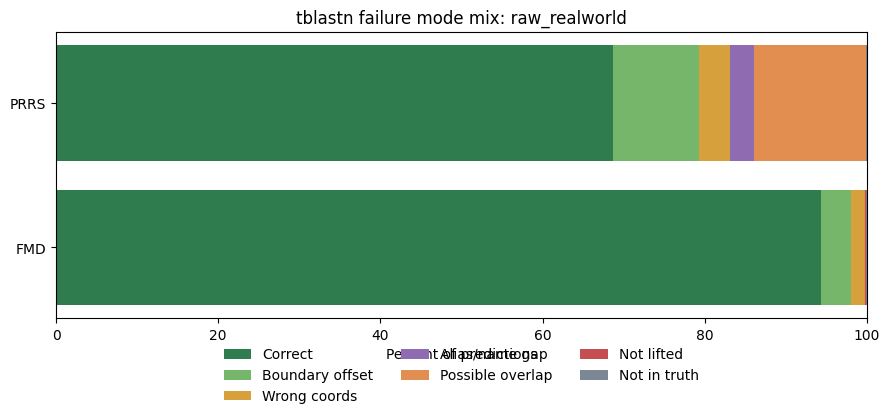

In [5]:
if not failure_modes.empty:
    failure_order = ['Correct', 'Boundary offset', 'Wrong coords', 'Alias/name gap', 'Possible overlap', 'Not lifted', 'Not in truth']
    plot_df = failure_modes.pivot_table(index='virus', columns='failure_mode', values='pct', fill_value=0)
    plot_df = plot_df.reindex(columns=failure_order, fill_value=0)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    left = pd.Series(0, index=plot_df.index, dtype=float)
    for failure in failure_order:
        values = plot_df[failure]
        ax.barh(plot_df.index, values, left=left.values, color=FAILURE_COLORS[failure], label=failure)
        left += values

    ax.set_xlim(0, 100)
    ax.set_xlabel('Percent of predictions')
    ax.set_ylabel('')
    ax.set_title(f'tblastn failure mode mix: {TIER}')
    ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.34), frameon=False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'tblastn_failure_modes.png', dpi=180, bbox_inches='tight')
    display(plot_df)


## Feature-Level Accuracy

Low rows here are the best candidates for real lifting improvements, after the tier has reduced annotation noise.

In [6]:
if tblastn_df.empty:
    by_gene = pd.DataFrame()
else:
    by_gene = summarize_comparison(tblastn_df, ['virus', 'pred_name'])
by_gene.to_csv(OUTPUT_DIR / 'tblastn_per_gene.tsv', sep='	', index=False)
by_gene.sort_values(['virus', 'coord_pct']).head(30)

,virus,pred_name,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,FMD,2A,98,73,82,0.9677,74.49,83.67
4,FMD,3B,98,95,96,0.9863,96.94,97.96
3,FMD,3A,98,97,97,0.9974,98.98,98.98
8,FMD,VP1,98,80,97,0.9882,81.63,98.98
9,FMD,VP2,98,97,97,0.9968,98.98,98.98
10,FMD,VP3,98,97,97,0.9898,98.98,98.98
11,FMD,VP4,98,97,97,0.9898,98.98,98.98
1,FMD,2B,98,98,98,1.0000,100.00,100.00
2,FMD,2C,98,98,98,1.0000,100.00,100.00
5,FMD,3Cpro,98,96,98,0.9996,97.96,100.00


## Review Cases

These are the non-correct predictions to inspect manually. For name-gap questions, compare `pred_name`, `truth_name`, and `best_overlap_name`.

In [7]:
if tblastn_df.empty:
    review_cases = pd.DataFrame()
else:
    review_cases = tblastn_df[tblastn_df['failure_mode'] != 'Correct'].copy()
    review_cases = review_cases.sort_values(['virus', 'failure_mode', 'record_id', 'pred_name'])
review_cases.to_csv(OUTPUT_DIR / 'tblastn_review_cases.tsv', sep='	', index=False)
review_cases.head(50)

,virus,record_id,method,pred_name,source_name,pred_start,pred_end,strand,status,coverage,...,truth_name,truth_start,truth_end,best_overlap_name,best_iou,iou,name_match,coord_correct,exact_match,failure_mode
904,FMD,AY687333.1,tblastn,VP1,None,3251.0,3880.0,+,ok,1.0000,...,VP1,3251.0,3886.0,VP1,0.9906,0.9906,True,True,False,Boundary offset
916,FMD,AY687334.1,tblastn,VP1,None,3250.0,3876.0,+,ok,1.0000,...,VP1,3250.0,3882.0,VP1,0.9905,0.9905,True,True,False,Boundary offset
1289,FMD,DQ533483.2,tblastn,2A,None,3893.0,3943.0,+,ok,0.9444,...,2A,3890.0,3943.0,2A,0.9444,0.9444,True,True,False,Boundary offset
941,FMD,DQ989304.1,tblastn,2A,None,3934.0,3984.0,+,ok,0.9444,...,2A,3931.0,3984.0,2A,0.9444,0.9444,True,True,False,Boundary offset
1049,FMD,DQ989313.1,tblastn,2A,None,3980.0,4030.0,+,ok,0.9444,...,2A,3977.0,4030.0,2A,0.9444,0.9444,True,True,False,Boundary offset
1092,FMD,DQ989317.1,tblastn,Lpro,None,1194.0,1784.0,+,ok,0.9801,...,Lpro,1182.0,1784.0,Lpro,0.9801,0.9801,True,True,False,Boundary offset
1104,FMD,DQ989318.1,tblastn,Lpro,None,1190.0,1780.0,+,ok,0.9801,...,Lpro,1178.0,1780.0,Lpro,0.9801,0.9801,True,True,False,Boundary offset
1277,FMD,GU931682.1,tblastn,2A,None,3892.0,3942.0,+,ok,0.9444,...,2A,3889.0,3942.0,2A,0.9444,0.9444,True,True,False,Boundary offset
1296,FMD,KJ754939.1,tblastn,Lpro,None,1113.0,1703.0,+,ok,0.9801,...,Lpro,1101.0,1703.0,Lpro,0.9801,0.9801,True,True,False,Boundary offset
1313,FMD,LC036265.1,tblastn,2A,None,3906.0,3956.0,+,ok,0.9444,...,2A,3909.0,3956.0,2A,0.9412,0.9412,True,True,False,Boundary offset
